## Homework 6 - due Friday, April 3 by 4 PM 

Name: Kristen Townsend

In [23]:
# Use this cell to import all necessary packages for the assignment 
import numpy as np
import matplotlib.pyplot as plt

### Problem 1: Exercise 6.1, page 220

Part 1

Equations for all the junctions:

$V_1: 4V_1 - V_2 - V_3 - V_4 = V_+$\
$V_2: -V_1 + 3V_2 - V_4 = 0$\
$V_3: -V_1 + 3V_3 - V_4 = V_+$\
$V_4: -V_1 - V_2 - V_3 + 4V_4 = 0$

In [4]:
# part 2
# defining the function
def Gauss_Elim(A,x,v):
    # pivoting
    for m in range(N):
        # find the row with the largest pivot element is
        pivot = m
        largest = np.abs(A[m,m])
        for i in range(m+1,N):
            if np.abs(A[i,m]) > largest:
                largest = np.abs(A[i,m])
                pivot = i

        # swap rows
        for j in range(N):
            A[m,j], A[pivot,j] = A[pivot,j], A[m,j]
        v[m], v[pivot] = v[pivot], v[m]

        # gaussian elimination with backsubtitution 

        for k in range(N):
            # divide by diagonal elements
            div = A[k,k]
            A[k,:] /= div
            v[k] /= div
            
            # subtract from lower rows
            for i in range(k+1,N):
                mult = A[i,k]
                A[i,:] -= mult*A[k,:]
                v[i] -= mult*v[k]

    # apply backsubstitution
    for m in range(N-1,-1,-1): # start at the end, move at one step to zero
        x[m] = v[m]
        for i in range(m+1,N):
            x[m] -= A[m,i]*x[i]

    return(x)

# defining constant
Vplus = 5.0 # volts
Vend = 0.0 # volts


# define matrix & vectors 
A = np.array([[4, -1, -1, -1],
             [-1,  3,  0, -1],
             [-1,  0,  3, -1], 
             [-1, -1, -1,  4]], float)
v = np.array([Vplus, Vend, Vplus, Vend], float)

# determine the number of variables solving for
N = len(v)
# create array for results, x
x = np.zeros(N, float)
print(A)


print(Gauss_Elim(A,x,v))

# checking my work
print(np.linalg.solve(A,v))


# print results
print("Resulting values (using Gaussian Elimination) for V1, V2, V3, and V4:")
print("V1:", round(x[0], 2), "Volts")
print("V2:", round(x[1], 2), "Volts")
print("V3:", round(x[2], 2), "Volts")
print("V4:", round(x[3], 2), "Volts")


[[ 4. -1. -1. -1.]
 [-1.  3.  0. -1.]
 [-1.  0.  3. -1.]
 [-1. -1. -1.  4.]]
[3.         1.66666667 3.33333333 2.        ]
[3.         1.66666667 3.33333333 2.        ]
Resulting values (using Gaussian Elimination) for V1, V2, V3, and V4:
V1: 3.0 Volts
V2: 1.67 Volts
V3: 3.33 Volts
V4: 2.0 Volts


##### Explanation: 

using gaussian elimination with pivoting.
steadily simplifies the matrix
pulled from work done previously in Lab Assignment 11.

Gaussian Elimination works by doing gradual transformations on the equations that do not change the solution to systematically eliminate the lower-diagonal coefficients. This creates easily solvable equations that can be plugged into each other to find a result for each unknown variable.


makes sense that the junctions closest to the voltage source have higher voltages than those further away. Is not increasing beyond the initial 5 volts, so I know the equations are set up properly

V3 has the most voltage at the junction. It is both close to the source and is connected to fewer junctions to pass the current along.

V2 has the least amount of voltage. It is after a junction that has many offshoots to pass current along.

### Problem 2: Exercise 6.4, page 228

In [ ]:
# defining constant
Vplus = 5.0 # volts
Vend = 0.0 # volts


# define matrix & vectors 
A = np.array([[4, -1, -1, -1],
             [-1,  3,  0, -1],
             [-1,  0,  3, -1], 
             [-1, -1, -1,  4]], float)
v = np.array([Vplus, Vend, Vplus, Vend], float)

# determine the number of variables solving for
N = len(v)
# create array for results, x
x = np.linalg.solve(A,v)


# print results
print("Resulting values (using LU Decomposition) for V1, V2, V3, and V4:")
print("V1:", round(x[0], 2), "Volts")
print("V2:", round(x[1], 2), "Volts")
print("V3:", round(x[2], 2), "Volts")
print("V4:", round(x[3], 2), "Volts")

Resulting values (using Gaussian Elimination) for V1, V2, V3, and V4:
V1: 3.0 Volts
V2: 1.67 Volts
V3: 3.33 Volts
V4: 2.0 Volts


#### Explanation: 

I already kind of did this one to check the results.

same set up, just found the results x using numpy.linalg.solve() to apply LU Decomposition to the original matrix

LU Decomposition works by separating the computationally exhausing factorization process on the matrix from the actual solving using the factored form and the right side of the equation. This is more efficient than Gaussian Elimination.


### Problem 3: Exercise 6.11, page 260

In [17]:
# part 1
# define the function
def f(x):
    return 1 - np.exp(-c*x)

# defining constant
c = 2

N = 50 # number of iterations
x = 1 # initial guess
print(x)

for i in range(N):
    x = f(x)
    print(x)
    if round(x,6) == round(f(x),6):
        # one more time for good measure
        x = f(x)
        print("Desired accuracy reached")
        break

# print results
print("x =", round(x,6))
        

1
0.8646647167633873
0.8225966691808597
0.8070247503317746
0.8009201942366403
0.7984747083247583
0.7974866394625985
0.797086049491047
0.796923413762181
0.7968573480008734
0.7968305046795713
0.7968195968986895
0.7968151643557075
0.7968133630966887
Desired accuracy reached
x = 0.796813


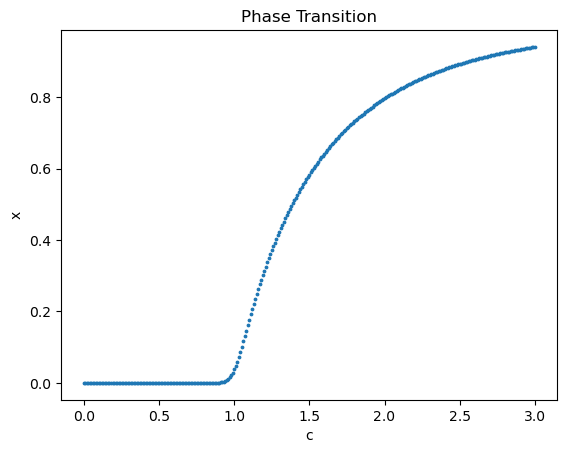

In [ ]:
# part 2
# define the function
def f(x,c):
    return 1 - np.exp(-c*x)

# defining constant
c = np.arange(0, 3.01, 0.01)
xpts = np.zeros(len(c))

N = 50 # number of iterations


for i in range(len(c)):
    x = 1 # initial guess

    # relaxation method
    for j in range(N):
        x = f(x,c[i])
        #print(x)
        xpts[i] = x


# plot results
plt.scatter(c, xpts, s=3)
plt.xlabel("c")
plt.ylabel("x")
plt.title("Phase Transition")

plt.show()


#### Explanation: 

relaxation method, single variable. covered in Class Notebook 13

cutting off... is it rounded to 10-6 okay?

part 2
made the function also take c as an input value
nested for loop to perform the relaxation method on each value of c

### Problem 4: Exercise 6.14, page 266

The initial equation:
$$ 5e^{-hc/{\lambda k_BT}} + hc/{\lambda k_BT} - 5 = 0 $$

Using the substitution
$$ x = \frac{hc}{\lambda k_B T} $$

Solving for $\lambda$ gives
$$ \lambda = \frac{hc}{k_B x T} $$

Substituting in the Wien displacement constant $b = hc/k_Bx$ where x is the solution to $5e^{-x} + x -5 = 0$ results in the following Wien displacement law
$$ \lambda = \frac{b}{T} $$

This leaves $\lambda$ as the solution to the initial equation.



In [33]:
# part b
# define function
def f(x):
    return 5*np.exp(-x) + x - 5

def binary_solve(x1, x2, f, accuracy):
    f1 = f(x1)
    f2 = f(x2)

    if f1 * f2 < 0:
        while np.abs(x2 - x1) > accuracy:
            xp = 0.5*(x2+x1)
            fp = f(xp)
            if fp*f1 > 0:
                x1, f1 = xp, fp
            else:
                x2, f2 = xp, fp
        result = 0.5 * (x1 + x2)
    else:
        result = -999.99
    
    return result

# defining constants
h = 6.62607015e-34 # Plank's constant
c = 299792458 # speed of light
kB = 1.380649e-23 # Boltzmann's constant

# initial guesses & accuracy
x1 = 2.0
x2 = 6.0
target = 1e-6

# call function
x_answer = binary_solve(x1,x2,f,target)
print(x_answer)

# finding displacement constant
disp_const = (h * c) / (kB * x_answer)
print(disp_const)

print("Wien displacement constant:", round(disp_const,6))

4.965114116668701
0.0028977720223463226
Wien displacement constant: 0.002898


In [37]:
# part c
wavelength = 502e-9 # meters

# finding the temperature of the sun
sun_temp = disp_const / wavelength

print("The surface of the Sun is approximately", round(sun_temp,2), "Kelvin")

The surface of the Sun is approximately 5772.45 Kelvin


#### Explanation: 

part a sort of substitutes in a loop

part b uses the binary search method on nonlinear equation $5e^{-x} + x -5 = 0$
first find x, then plug into $b = hc/k_Bx$ to find the dispacement constant b
want the non-zero answer
actual answer for the displacement constant (as found on the internet) is 2.897771955e-3
accurate to 10e-6

part c uses the formula $\lambda = b/T$
solved to equal T: $T = b/\lambda$
surface of the sun, according to the internet, is approximately 5700 to 5800 Kelvin. My result fits within this range!

### Problem 5: 

part a

Take the partial derivatives of
$$ U(x,y) = x^4 + y^4 - 2x^2 - 4y^2 + xy + 5x $$

partial relative to x
$$ dU_x = 4x^3 - 4x + y + 5 $$
This will be my f(x,y) equation

partial relative to y
$$ dU_y = 4y^3 - 8y + x $$
This will be my g(x,y) equation

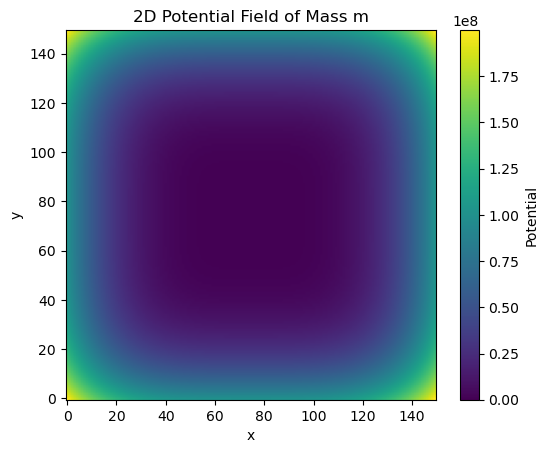

In [52]:
# part b
# define the function U(x,y)
def U(x,y):
    return x**4 + y**4 - 2*x**2 - 4*y**2 + x*y + 5*x

# values for x, y grid
side = 100 #meters
N = 150

x = np.linspace(-side, side, N)
y = np.linspace(-side, side, N)

# initializing a 2D array of zeros to hold U(x,y) results
potential = np.zeros((len(x),len(y)))

# loop through points to fill previous array
for n in range(N):
    for m in range(N):
        a = x[n]
        b = y[m]
        potential[m,n] = U(a,b) # row, column


# plotting details
plt.imshow(potential, origin="lower") 
plt.colorbar(label="Potential")
plt.xlabel('x')
plt.ylabel('y')
plt.title("2D Potential Field of Mass m")
plt.viridis()
plt.show()

#### Explanation: 

part b
made a density plot of U(x,y) by iterating over the grid
because there is an equilibrium point when the gradient of the potential is zero (both $dU_x$ and $dU_y$ are zero).

need to find a way to get the x and y axis to show the actual distance, not the number of points on the axis